# Assignment 06 — Avocado Price: Dự báo giá bằng RNN

Notebook dùng toàn bộ 54 vùng và 2 loại avocado. Mỗi cặp `region–type` là một chuỗi tuần riêng;
một RNN chung học các mẫu biến động đã chuẩn hóa và dự báo `AveragePrice` của tuần kế tiếp từ
12 tuần gần nhất. PyTorch và Keras được so sánh trên cùng split thời gian 80/10/10.


## 1. Thiết lập môi trường và tính tái lập

Seed được cố định cho NumPy, PyTorch và Keras. PyTorch ưu tiên Apple Metal qua
`torch.device("mps")`; nếu MPS không khả dụng, notebook tự chuyển sang CPU và báo rõ thiết bị.


In [1]:
import os
os.environ.setdefault("PYTHONHASHSEED", "42")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/a06-matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/a06-cache")

from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from tensorflow import keras

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"PyTorch {torch.__version__} | device={DEVICE}")
print(f"TensorFlow {tf.__version__} | devices={tf.config.list_physical_devices()}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)


PyTorch 2.14.0 | device=mps
TensorFlow 2.21.0 | devices=[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Chuỗi thời gian theo nhóm và cửa sổ trượt

Mỗi cặp `(region, type)` là một chuỗi tuần độc lập
$p_1^{(r,c)},\ldots,p_T^{(r,c)}$. Với $L=12$, notebook tạo:
$$\mathbf{x}^{(i,r,c)}=[p_i^{(r,c)},\ldots,p_{i+L-1}^{(r,c)}],\qquad y^{(i,r,c)}=p_{i+L}^{(r,c)}.$$

Mười hai tuần cung cấp khoảng một quý lịch sử. Cửa sổ không bao giờ đi xuyên ranh giới nhóm. Mỗi nhóm
được split tuần tự 80/10/10 rồi mới gộp samples, nhờ đó mọi vùng/type đều góp mặt trong ba tập và
target validation/test luôn muộn hơn target train của cùng nhóm.


In [2]:
def sliding_windows(values, lookback):
    """Bien chuoi 1 chieu thanh cac cap (cua so qua khu, gia ke tiep)."""
    values = np.asarray(values, dtype=np.float32)
    X = np.stack([values[i : i + lookback] for i in range(len(values) - lookback)])
    y = values[lookback:]
    return X[..., None], y[:, None]

demo_series = np.array([1.00, 1.05, 1.02, 1.10, 1.12, 1.15], dtype=np.float32)
demo_X, demo_y = sliding_windows(demo_series, lookback=3)
print("X shape:", demo_X.shape, "| y shape:", demo_y.shape)
print("Cua so dau:", demo_X[0, :, 0], "-> muc tieu:", demo_y[0, 0])


X shape: (3, 3, 1) | y shape: (3, 1)
Cua so dau: [1.   1.05 1.02] -> muc tieu: 1.1


## 3. Vanilla RNN và hidden state

Ở tuần $t$, RNN cập nhật bộ nhớ bằng:
$$a_t=x_tW_{xh}+h_{t-1}W_{hh}+b_h,\qquad h_t=\tanh(a_t),$$
$$\hat y=W_{hy}h_{12}+b_y.$$

Hidden state tóm tắt mức giá và biến động của các tuần trước. $W_{xh}$ biến đổi giá hiện tại;
$W_{hh}$ truyền ký ức; tanh tạo phi tuyến và giới hạn activation. Đây là many-to-one RNN: 12 input
tuần tạo đúng một `AveragePrice` tuần kế tiếp. Một bộ trọng số chung được học từ 108 chuỗi đã chuẩn hóa.


In [3]:
def numpy_rnn_step(x_t, h_previous, W_xh, W_hh, bias):
    """Mot buoc forward cua vanilla RNN dung tanh."""
    return np.tanh(x_t @ W_xh + h_previous @ W_hh + bias)

rng = np.random.default_rng(RANDOM_STATE)
x_t = np.array([[0.25]], dtype=np.float32)
h_previous = np.zeros((1, 4), dtype=np.float32)
W_xh = rng.normal(0, 0.2, size=(1, 4))
W_hh = rng.normal(0, 0.2, size=(4, 4))
bias = np.zeros((1, 4))
h_t = numpy_rnn_step(x_t, h_previous, W_xh, W_hh, bias)
print("Hidden state h_t:", np.round(h_t, 4))


Hidden state h_t: [[ 0.0152 -0.052   0.0375  0.047 ]]


## 4. Hàm mất mát, tối ưu và BPTT

Mô hình tối ưu $\mathcal{L}=\frac{1}{N}\sum_i(y_i-\hat y_i)^2$. BPTT unroll 12 tuần và truyền
gradient từ output về các hidden state trước đó. Adam dùng moment để ổn định cập nhật; scheduler giảm
learning rate khi validation loss không cải thiện; gradient clipping trong PyTorch giới hạn chuẩn
gradient ở 1.0. Khi báo cáo, prediction được inverse bằng scaler đúng nhóm rồi mới tính MAE, RMSE,
MAPE và $R^2$, vì metric trên thang chuẩn hóa không có ý nghĩa trực tiếp về giá.


In [4]:
def mse_loss(y_true, y_pred):
    return np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)

demo_true = np.array([1.10, 1.20, 1.30])
demo_pred = np.array([1.08, 1.24, 1.27])
print(f"MSE minh hoa: {mse_loss(demo_true, demo_pred):.6f}")


MSE minh hoa: 0.000967


## 4.1. Unroll RNN, dạng tensor và chia sẻ tham số

Một RNN có thể được **unroll** thành $L$ bản sao của cùng một cell. Đây không phải $L$ mạng khác nhau:
$W_{xh}$, $W_{hh}$ và bias được chia sẻ ở mọi thời điểm. Với mini-batch, tensor input có dạng
`(batch_size, sequence_length, input_size)`; notebook này có `input_size=1`. Hidden state có dạng
`(num_layers, batch_size, hidden_size)` trong PyTorch. Trạng thái đầu $h_0$ mặc định là vector 0.

Bài toán đang dùng là **many-to-one**: RNN đọc toàn bộ cửa sổ nhưng chỉ hidden state cuối $h_L$
đi qua lớp tuyến tính để tạo một giá dự báo. Many-to-many sẽ cần output tại từng bước, còn
sequence-to-sequence thường có encoder–decoder.

Với input dimension $d$, hidden size $H$ và output size $o$, phần recurrent cần xấp xỉ
$dH+H^2+H$ tham số; lớp output cần $Ho+o$. PyTorch tách recurrent bias thành hai vector nên có
thêm $H$ tham số so với cách viết một bias trong công thức/Keras.


In [5]:
def numpy_rnn_forward(sequence, hidden_size=4, seed=42):
    """Unroll mot vanilla RNN qua toan bo sequence va tra lai moi hidden state."""
    sequence = np.asarray(sequence, dtype=np.float32).reshape(-1, 1)
    generator = np.random.default_rng(seed)
    W_xh = generator.normal(0, 0.25, size=(1, hidden_size))
    W_hh = generator.normal(0, 0.25, size=(hidden_size, hidden_size))
    b_h = np.zeros((1, hidden_size))
    W_hy = generator.normal(0, 0.25, size=(hidden_size, 1))
    b_y = np.zeros((1, 1))
    hidden = np.zeros((1, hidden_size))
    hidden_states = []
    for value in sequence:
        hidden = numpy_rnn_step(value.reshape(1, 1), hidden, W_xh, W_hh, b_h)
        hidden_states.append(hidden.copy())
    prediction = hidden @ W_hy + b_y
    return np.concatenate(hidden_states, axis=0), float(prediction.item())

demo_hidden_states, demo_output = numpy_rnn_forward(demo_series[:4])
print("Hidden states shape:", demo_hidden_states.shape)
print("Many-to-one output:", round(demo_output, 6))
display(pd.DataFrame(demo_hidden_states, columns=[f"h{i + 1}" for i in range(4)]))

input_size, hidden_size, output_size = 1, 64, 1
keras_parameter_count = input_size * hidden_size + hidden_size**2 + hidden_size + hidden_size * output_size + output_size
pytorch_parameter_count = keras_parameter_count + hidden_size
print("So tham so ly thuyet — Keras:", keras_parameter_count)
print("So tham so ly thuyet — PyTorch (hai recurrent bias):", pytorch_parameter_count)


Hidden states shape: (4, 4)
Many-to-one output: 0.095391


,h1,h2,h3,h4
0,0.076032,-0.254292,0.185442,0.230901
1,0.068212,-0.241729,0.212607,0.147634
2,0.062485,-0.208236,0.195137,0.139026
3,0.070117,-0.235745,0.212635,0.167962


So tham so ly thuyet — Keras: 4289
So tham so ly thuyet — PyTorch (hai recurrent bias): 4353


## 4.2. BPTT, vanishing/exploding gradient và các biến thể RNN

Khi BPTT đi qua nhiều bước, gradient chứa tích nhiều Jacobian
$\partial h_t/\partial h_{t-1}$. Nếu chuẩn của tích nhỏ hơn 1, gradient **biến mất** và RNN khó nhớ
quan hệ xa; nếu lớn hơn 1, gradient **bùng nổ**. Hàm tanh còn có đạo hàm
$1-\tanh^2(z)$ rất nhỏ khi activation bão hòa gần $-1$ hoặc $1$.

Notebook giảm rủi ro bằng cửa sổ hữu hạn, chuẩn hóa đầu vào và gradient clipping ở PyTorch.
Dropout 0.2 regularize hidden representation; early stopping chọn epoch theo validation loss.
**LSTM** thêm cell state và các cổng input/forget/output; **GRU** dùng update/reset gate. Hai biến thể
thường giữ phụ thuộc dài tốt hơn, nhưng vanilla RNN được chọn ở đây để thể hiện rõ phương trình cơ bản.


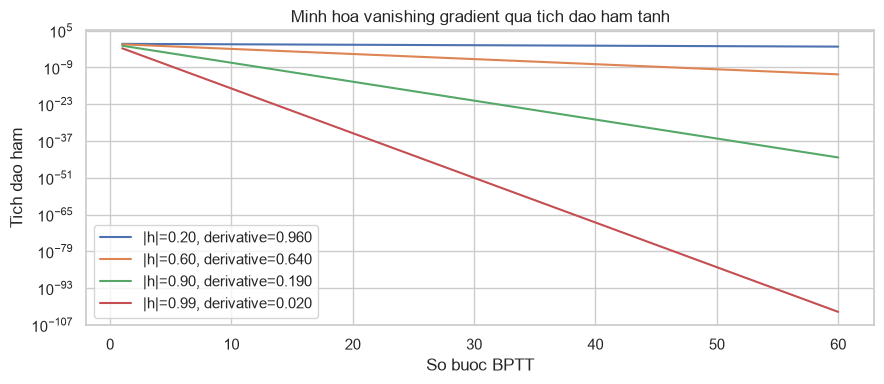

In [6]:
activation_levels = np.array([0.20, 0.60, 0.90, 0.99])
tanh_derivatives = 1.0 - activation_levels**2
steps = np.arange(1, 61)

fig, ax = plt.subplots(figsize=(9, 4))
for activation, derivative in zip(activation_levels, tanh_derivatives):
    ax.plot(steps, derivative**steps, label=f"|h|={activation:.2f}, derivative={derivative:.3f}")
ax.set_yscale("log")
ax.set(title="Minh hoa vanishing gradient qua tich dao ham tanh", xlabel="So buoc BPTT", ylabel="Tich dao ham")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Đọc và mô tả dữ liệu

Dataset gồm giá trung bình, volume, các PLU/bag size, loại avocado và vùng. Cột chỉ số
`Unnamed: 0` không mang thông tin và được loại. Khóa `(Date, region, type)` phải duy nhất.


In [7]:
def resolve_data_path():
    candidates = [
        Path("../data/avocado.csv"),
        Path("data/avocado.csv"),
        Path("src/Assignment 06/Avocado Price/data/avocado.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Khong tim thay avocado.csv trong cac duong dan du kien.")

DATA_PATH = resolve_data_path()
DATASET_DIR = DATA_PATH.parent.parent
MODEL_DIR = DATASET_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PYTORCH_WEIGHTS_PATH = MODEL_DIR / "pytorch_rnn.pt"
KERAS_WEIGHTS_PATH = MODEL_DIR / "keras_rnn.weights.h5"
METADATA_PATH = MODEL_DIR / "metadata.json"
GROUP_SEPARATOR = "|||"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.sort_values(["region", "type", "Date"]).reset_index(drop=True)
required_columns = {"Date", "AveragePrice", "Total Volume", "type", "year", "region"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Thieu cot bat buoc: {sorted(missing_columns)}")
if df.duplicated(["Date", "region", "type"]).any():
    raise ValueError("Khoa (Date, region, type) bi trung.")
if df["AveragePrice"].isna().any():
    raise ValueError("AveragePrice co missing value.")

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
group_sizes = df.groupby(["region", "type"]).size().rename("weeks")
print(f"Data path: {DATA_PATH}")
print(f"Shape: {df.shape} | Date: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Regions: {df['region'].nunique()} | Types: {df['type'].nunique()} | Groups: {len(group_sizes)}")
display(audit)
display(df.describe(include="all").T)
display(group_sizes.describe().to_frame().T)
display(df.head())


Data path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Avocado Price/data/avocado.csv
Shape: (18249, 13) | Date: 2015-01-04 -> 2018-03-25
Regions: 54 | Types: 2 | Groups: 108


,dtype,missing,unique
Date,datetime64[us],0,169
AveragePrice,float64,0,259
Total Volume,float64,0,18237
4046,float64,0,17702
4225,float64,0,18103
4770,float64,0,12071
Total Bags,float64,0,18097
Small Bags,float64,0,17321
Large Bags,float64,0,15082
XLarge Bags,float64,0,5588


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,18249,NaN,NaN,NaN,2016-08-13 23:30:43.498274,2015-01-04 00:00:00,2015-10-25 00:00:00,2016-08-14 00:00:00,2017-06-04 00:00:00,2018-03-25 00:00:00,NaN
AveragePrice,18249.0,NaN,NaN,NaN,1.405978,0.44,1.1,1.37,1.66,3.25,0.402677
Total Volume,18249.0,NaN,NaN,NaN,850644.013009,84.56,10838.58,107376.76,432962.29,62505646.52,3453545.355399
4046,18249.0,NaN,NaN,NaN,293008.424531,0.0,854.07,8645.3,111020.2,22743616.17,1264989.081763
4225,18249.0,NaN,NaN,NaN,295154.568356,0.0,3008.78,29061.02,150206.86,20470572.61,1204120.401135
4770,18249.0,NaN,NaN,NaN,22839.735993,0.0,0.0,184.99,6243.42,2546439.11,107464.068435
Total Bags,18249.0,NaN,NaN,NaN,239639.20206,0.0,5088.64,39743.83,110783.37,19373134.37,986242.399216
Small Bags,18249.0,NaN,NaN,NaN,182194.686696,0.0,2849.42,26362.82,83337.67,13384586.8,746178.514962
Large Bags,18249.0,NaN,NaN,NaN,54338.088145,0.0,127.47,2647.71,22029.25,5719096.61,243965.964547
XLarge Bags,18249.0,NaN,NaN,NaN,3106.426507,0.0,0.0,0.0,132.5,551693.65,17692.894652


,count,mean,std,min,25%,50%,75%,max
weeks,108.0,168.972222,0.288675,166.0,169.0,169.0,169.0,169.0


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany


## 6. EDA và phân bố dữ liệu

Các biểu đồ so sánh phân phối `AveragePrice` theo type, xu hướng trung bình tuần, phân phối
`Total Volume` trên log scale và mức giá giữa những vùng có volume lớn nhất.


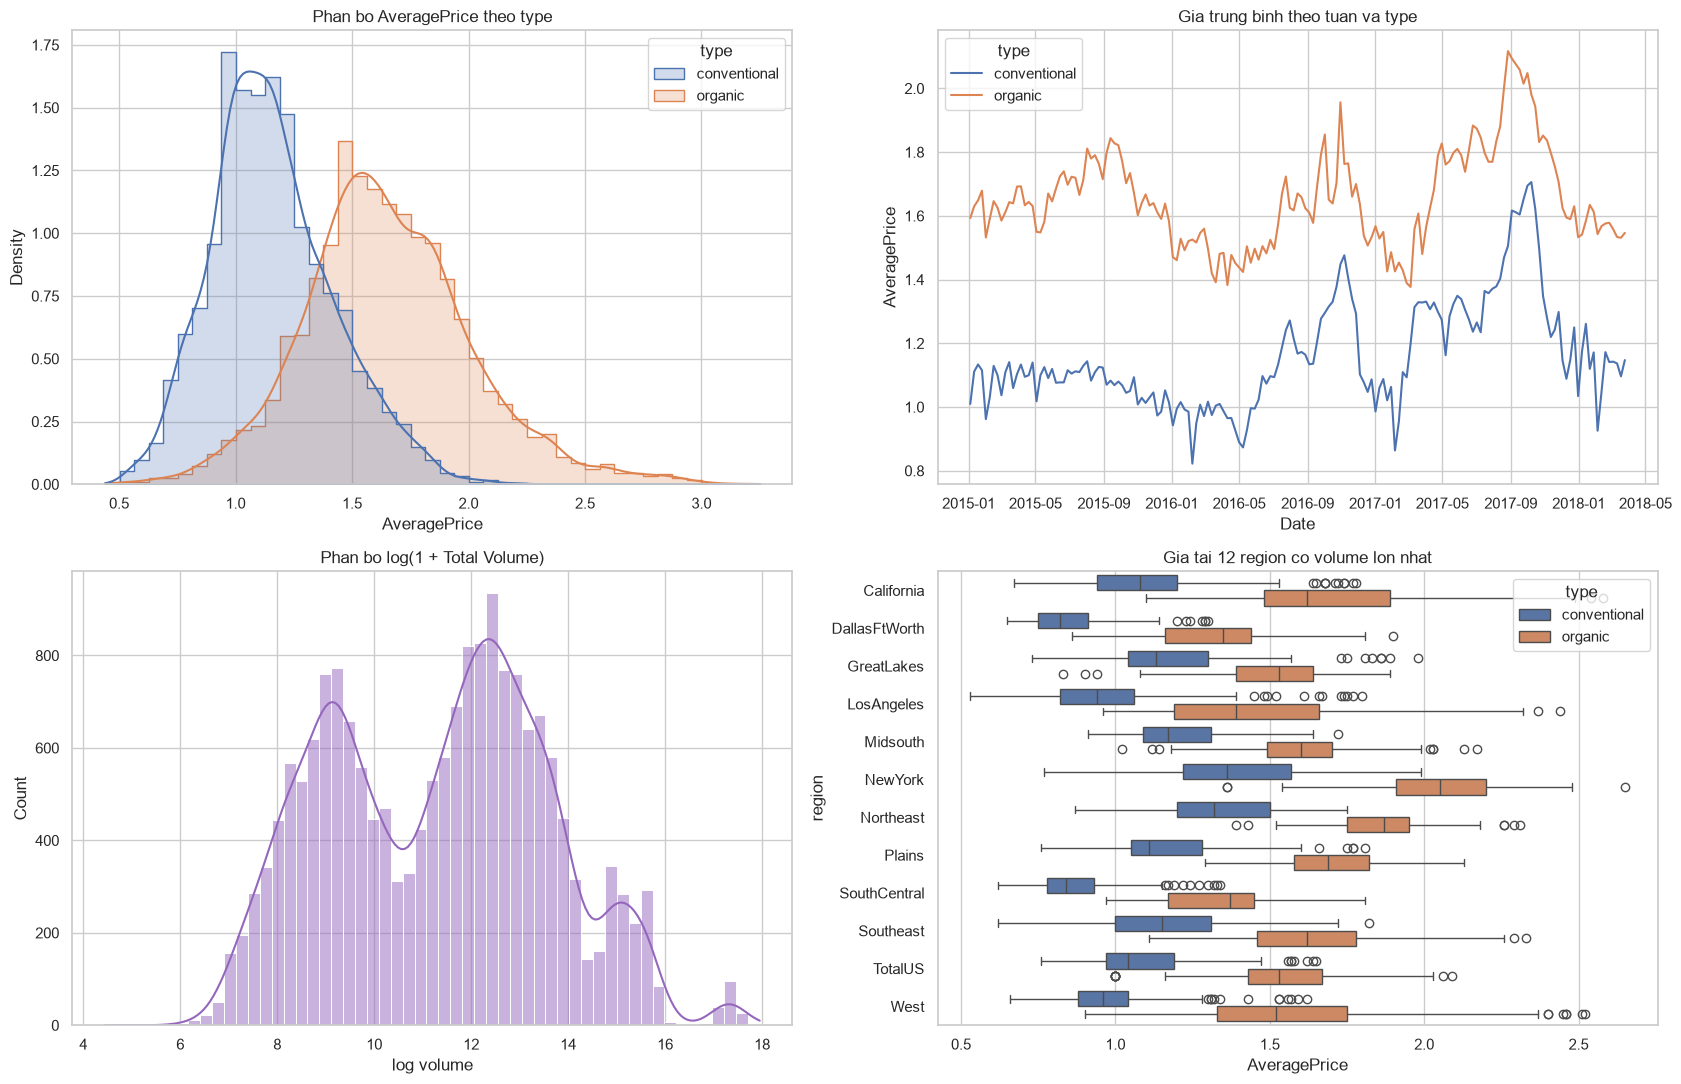

type,conventional,organic
month,,
1,1.069,1.553
2,1.017,1.531
3,1.126,1.538
4,1.142,1.606
5,1.090,1.604
6,1.149,1.670
7,1.212,1.712
8,1.235,1.790
9,1.295,1.851


In [8]:
weekly_by_type = (
    df.groupby(["Date", "type"], as_index=False)["AveragePrice"].mean()
)
top_regions = (
    df.groupby("region")["Total Volume"].sum().nlargest(12).index.tolist()
)
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
sns.histplot(
    data=df, x="AveragePrice", hue="type", bins=45, kde=True,
    stat="density", common_norm=False, element="step", ax=axes[0, 0]
)
axes[0, 0].set(title="Phan bo AveragePrice theo type")
sns.lineplot(data=weekly_by_type, x="Date", y="AveragePrice", hue="type", ax=axes[0, 1])
axes[0, 1].set(title="Gia trung binh theo tuan va type")
sns.histplot(np.log1p(df["Total Volume"]), bins=55, kde=True, ax=axes[1, 0], color="tab:purple")
axes[1, 0].set(title="Phan bo log(1 + Total Volume)", xlabel="log volume")
sns.boxplot(
    data=df[df["region"].isin(top_regions)], x="AveragePrice", y="region",
    hue="type", orient="h", ax=axes[1, 1]
)
axes[1, 1].set(title="Gia tai 12 region co volume lon nhat")
plt.tight_layout()
plt.show()

seasonal = df.assign(month=df["Date"].dt.month).groupby(["month", "type"])["AveragePrice"].mean().unstack()
display(seasonal.style.format("{:.3f}"))


## 6.1. Chất lượng panel data, seasonality và quan hệ giá–volume

Avocado là panel data: cùng một ngày xuất hiện ở nhiều vùng/type. Vì vậy phải đánh giá độ phủ theo
nhóm thay vì coi Date lặp là duplicate. Notebook kiểm tra số tuần, khoảng ngày và gap giữa các quan sát
trong từng nhóm; một nhóm thiếu vài tuần vẫn có thể tạo cửa sổ nhưng cần được nhận diện.

Giá organic và conventional có cấu trúc khác nhau, volume lệch phải mạnh và chênh nhiều bậc độ lớn
giữa region. Phân tích theo năm/tháng giúp nhận ra trend và seasonality; scatter log-volume kiểm tra
quan hệ giá–cầu nhưng chỉ mang tính mô tả, không chứng minh quan hệ nhân quả.


Phan bo so quan sat theo group:


,number_of_groups
observations,
166,1
169,107


Phan bo khoang cach ngay giua hai quan sat lien tiep:


,count
Date,
7.0,18139
14.0,1
21.0,1


10 group co bien dong gia tuong doi lon nhat:


,region,type,observations,mean_price,std_price,coefficient_of_variation
73,Portland,organic,169,1.588935,0.474608,0.298695
7,Boise,organic,169,1.620237,0.459381,0.283527
87,Seattle,organic,169,1.715385,0.474803,0.276791
95,Spokane,organic,169,1.775207,0.455395,0.256531
25,Denver,organic,169,1.363195,0.349110,0.256097
97,StLouis,organic,169,1.675503,0.426814,0.254738
44,LosAngeles,conventional,169,0.976450,0.244190,0.250080
66,PhoenixTucson,conventional,169,0.728225,0.178026,0.244466
19,CincinnatiDayton,organic,169,1.402899,0.342585,0.244198
28,GrandRapids,conventional,169,1.325030,0.316467,0.238838


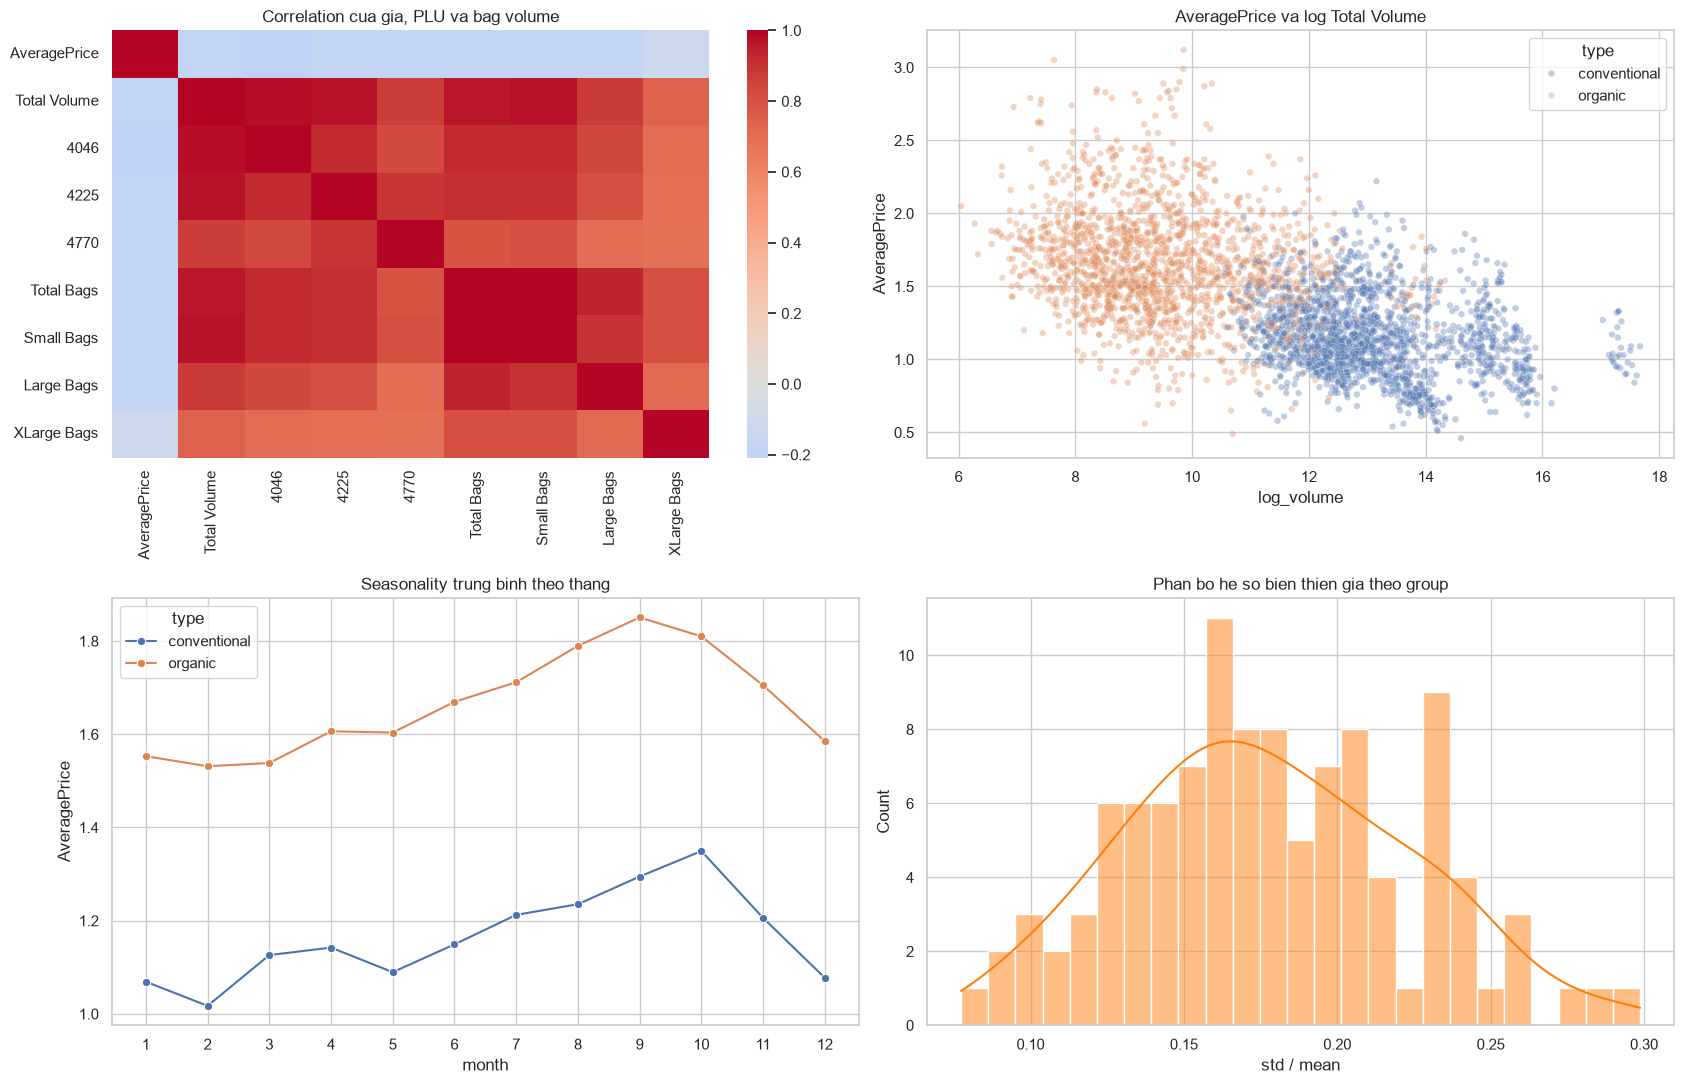

In [9]:
group_quality = (
    df.groupby(["region", "type"])
    .agg(
        observations=("Date", "size"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        mean_price=("AveragePrice", "mean"),
        std_price=("AveragePrice", "std"),
        total_volume=("Total Volume", "sum"),
    )
    .reset_index()
)
group_quality["coefficient_of_variation"] = group_quality["std_price"] / group_quality["mean_price"]
weekly_gaps = (
    df.sort_values(["region", "type", "Date"])
    .groupby(["region", "type"])["Date"]
    .diff()
    .dt.days
)
print("Phan bo so quan sat theo group:")
display(group_quality["observations"].value_counts().sort_index().rename("number_of_groups").to_frame())
print("Phan bo khoang cach ngay giua hai quan sat lien tiep:")
display(weekly_gaps.value_counts().sort_index().rename("count").to_frame())

type_year_summary = (
    df.groupby(["year", "type"])
    .agg(
        samples=("AveragePrice", "size"),
        mean_price=("AveragePrice", "mean"),
        median_price=("AveragePrice", "median"),
        std_price=("AveragePrice", "std"),
        total_volume=("Total Volume", "sum"),
    )
)
display(type_year_summary.style.format({
    "mean_price": "{:.3f}", "median_price": "{:.3f}",
    "std_price": "{:.3f}", "total_volume": "{:,.0f}",
}))
print("10 group co bien dong gia tuong doi lon nhat:")
display(group_quality.nlargest(10, "coefficient_of_variation")[[
    "region", "type", "observations", "mean_price", "std_price", "coefficient_of_variation"
]])

numeric_columns = [
    "AveragePrice", "Total Volume", "4046", "4225", "4770",
    "Total Bags", "Small Bags", "Large Bags", "XLarge Bags",
]
correlation = df[numeric_columns].corr()
scatter_sample = df.sample(min(3500, len(df)), random_state=RANDOM_STATE).copy()
scatter_sample["log_volume"] = np.log1p(scatter_sample["Total Volume"])
month_type = (
    df.assign(month=df["Date"].dt.month)
    .groupby(["month", "type"], as_index=False)["AveragePrice"].mean()
)

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
sns.heatmap(correlation, cmap="coolwarm", center=0, ax=axes[0, 0])
axes[0, 0].set(title="Correlation cua gia, PLU va bag volume")
sns.scatterplot(
    data=scatter_sample, x="log_volume", y="AveragePrice", hue="type",
    alpha=0.35, s=22, ax=axes[0, 1]
)
axes[0, 1].set(title="AveragePrice va log Total Volume")
sns.lineplot(data=month_type, x="month", y="AveragePrice", hue="type", marker="o", ax=axes[1, 0])
axes[1, 0].set(title="Seasonality trung binh theo thang", xticks=range(1, 13))
sns.histplot(group_quality["coefficient_of_variation"], bins=25, kde=True, ax=axes[1, 1], color="tab:orange")
axes[1, 1].set(title="Phan bo he so bien thien gia theo group", xlabel="std / mean")
plt.tight_layout()
plt.show()


## 7. Tạo sequence theo nhóm và split 80/10/10

Mỗi nhóm được sort theo ngày, tạo cửa sổ riêng rồi split tuần tự 80/10/10. Scaler của mỗi nhóm
chỉ fit tới target train cuối của chính nhóm đó. Cách này giữ thang giá riêng của vùng/type,
đồng thời một RNN chung có thể học từ tất cả chuỗi.


In [10]:
LOOKBACK = 12
split_X = {"train": [], "validation": [], "test": []}
split_y = {"train": [], "validation": [], "test": []}
split_raw_y = {"test": []}
split_baseline = {"test": []}
split_groups = {"test": []}
split_dates = {"test": []}
group_scalers = {}
groups_metadata = []

for (region, avocado_type), group in df.groupby(["region", "type"], sort=True):
    group = group.sort_values("Date").reset_index(drop=True)
    raw_prices = group["AveragePrice"].to_numpy(dtype=np.float32)
    n_samples = len(raw_prices) - LOOKBACK
    if n_samples < 10:
        raise ValueError(f"Nhom {(region, avocado_type)} khong du du lieu.")
    n_train = int(n_samples * 0.80)
    n_val = int(round(n_samples * 0.10))
    n_test = n_samples - n_train - n_val
    train_target_end = LOOKBACK + n_train

    scaler = StandardScaler().fit(raw_prices[:train_target_end].reshape(-1, 1))
    scaled_prices = scaler.transform(raw_prices.reshape(-1, 1)).reshape(-1).astype(np.float32)
    X_group, y_group = sliding_windows(scaled_prices, LOOKBACK)
    train_end = n_train
    val_end = n_train + n_val
    group_key = f"{region}{GROUP_SEPARATOR}{avocado_type}"

    split_X["train"].append(X_group[:train_end])
    split_y["train"].append(y_group[:train_end])
    split_X["validation"].append(X_group[train_end:val_end])
    split_y["validation"].append(y_group[train_end:val_end])
    split_X["test"].append(X_group[val_end:])
    split_y["test"].append(y_group[val_end:])
    split_raw_y["test"].extend(raw_prices[LOOKBACK + val_end :].tolist())
    split_baseline["test"].extend(raw_prices[LOOKBACK + val_end - 1 : -1].tolist())
    split_groups["test"].extend([group_key] * n_test)
    split_dates["test"].extend(group["Date"].iloc[LOOKBACK + val_end :].tolist())

    group_scalers[group_key] = {
        "mean": float(scaler.mean_[0]),
        "scale": float(scaler.scale_[0]),
    }
    groups_metadata.append({"region": region, "type": avocado_type, "weeks": len(group)})

X_train = np.concatenate(split_X["train"]).astype(np.float32)
y_train = np.concatenate(split_y["train"]).astype(np.float32)
X_val = np.concatenate(split_X["validation"]).astype(np.float32)
y_val = np.concatenate(split_y["validation"]).astype(np.float32)
X_test = np.concatenate(split_X["test"]).astype(np.float32)
y_test = np.concatenate(split_y["test"]).astype(np.float32)
y_test_raw = np.asarray(split_raw_y["test"], dtype=np.float32)
baseline_test = np.asarray(split_baseline["test"], dtype=np.float32)
test_group_keys = np.asarray(split_groups["test"], dtype=object)
test_dates = pd.to_datetime(split_dates["test"])

total_samples = len(X_train) + len(X_val) + len(X_test)
assert np.isfinite(X_train).all() and np.isfinite(y_train).all()
assert np.isfinite(X_val).all() and np.isfinite(y_val).all()
assert np.isfinite(X_test).all() and np.isfinite(y_test).all()
split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples": [len(X_train), len(X_val), len(X_test)],
    "ratio (%)": np.array([len(X_train), len(X_val), len(X_test)]) / total_samples * 100,
})
display(split_table)
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Group scalers:", len(group_scalers))


,split,samples,ratio (%)
0,train,13498,79.620126
1,validation,1727,10.186988
2,test,1728,10.192886


Shapes: (13498, 12, 1) (1727, 12, 1) (1728, 12, 1)
Group scalers: 108


## 8. Kiến trúc, hyperparameter và hàm dùng chung

Hai framework cùng dùng `SimpleRNN/nn.RNN(1 → 64, tanh) → Dropout(0.2) → Linear(1)`, Adam
`learning_rate=1e-3`, MSE và batch size 64. Ngân sách được tăng lên **tối đa 250 epoch**, huấn luyện
ít nhất 30 epoch và early stopping patience 25. `ReduceLROnPlateau` giảm learning rate một nửa sau
5 epoch validation không cải thiện. Cấu hình chung giúp phép so sánh tập trung vào framework.


In [11]:
MODEL_CONFIG = {
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.2,
}
MAX_EPOCHS = 250
MIN_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 25


class TorchPriceRNN(nn.Module):
    def __init__(self, config=MODEL_CONFIG):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=config["input_size"],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            nonlinearity="tanh",
            batch_first=True,
        )
        self.dropout = nn.Dropout(config["dropout"])
        self.output = nn.Linear(config["hidden_size"], 1)

    def forward(self, inputs):
        sequence_output, _ = self.rnn(inputs)
        return self.output(self.dropout(sequence_output[:, -1, :]))


def build_keras_rnn(model_name="price_rnn"):
    inputs = keras.Input(shape=(LOOKBACK, MODEL_CONFIG["input_size"]), name="price_sequence")
    hidden = keras.layers.SimpleRNN(
        MODEL_CONFIG["hidden_size"], activation="tanh", name="simple_rnn"
    )(inputs)
    hidden = keras.layers.Dropout(MODEL_CONFIG["dropout"], name="dropout")(hidden)
    outputs = keras.layers.Dense(1, name="price_output")(hidden)
    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="mse")
    return model


def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).float())
    generator = torch.Generator().manual_seed(RANDOM_STATE)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
    )


def run_torch_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    criterion = nn.MSELoss()
    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total_loss += loss.item() * len(batch_X)
    return total_loss / len(loader.dataset)


def predict_torch(model, X):
    model.eval()
    predictions = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=BATCH_SIZE)
    with torch.no_grad():
        for (batch_X,) in loader:
            predictions.append(model(batch_X.to(DEVICE)).cpu().numpy())
    return np.concatenate(predictions).reshape(-1)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100,
        "R2": r2_score(y_true, y_pred),
    }


## 9. Huấn luyện RNN bằng PyTorch

PyTorch ưu tiên MPS, dùng mini-batch, gradient clipping và lưu state có validation loss tốt nhất
vào `models/pytorch_rnn.pt`.


In [12]:
train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)

torch_model = TorchPriceRNN().to(DEVICE)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
torch_history = {"loss": [], "val_loss": [], "learning_rate": []}

torch_start = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_torch_epoch(torch_model, train_loader, optimizer)
    val_loss = run_torch_epoch(torch_model, val_loader)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    torch_history["loss"].append(train_loss)
    torch_history["val_loss"].append(val_loss)
    torch_history["learning_rate"].append(current_lr)

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = copy.deepcopy(torch_model.state_dict())
        epochs_without_improvement = 0
        torch.save(
            {"state_dict": best_state, "model_config": MODEL_CONFIG},
            PYTORCH_WEIGHTS_PATH,
        )
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | train={train_loss:.6f} | "
            f"val={val_loss:.6f} | lr={current_lr:.2e}"
        )
    if epoch >= MIN_EPOCHS and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping tai epoch {epoch}.")
        break

torch_train_seconds = time.perf_counter() - torch_start
torch_model.load_state_dict(best_state)
torch_scaled_prediction = predict_torch(torch_model, X_test)
print(f"PyTorch hoan tat trong {torch_train_seconds:.2f}s; best val loss={best_val_loss:.6f}")


Epoch 001 | train=0.506085 | val=0.853458 | lr=1.00e-03


Epoch 010 | train=0.442515 | val=0.857946 | lr=1.00e-03


Epoch 020 | train=0.438074 | val=0.958861 | lr=2.50e-04


Epoch 030 | train=0.435213 | val=0.840648 | lr=1.25e-04


Early stopping tai epoch 32.
PyTorch hoan tat trong 22.72s; best val loss=0.773740


## 10. Huấn luyện RNN bằng Keras

Keras dùng cùng kiến trúc/hyperparameter. `ModelCheckpoint` lưu best weights vào
`models/keras_rnn.weights.h5`.


In [13]:
MODEL_NAME = "avocado_price_rnn"

keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)
keras_model = build_keras_rnn(MODEL_NAME)
keras_callbacks = [
    keras.callbacks.ModelCheckpoint(
        KERAS_WEIGHTS_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=0,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        start_from_epoch=MIN_EPOCHS,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

keras_start = time.perf_counter()
keras_fit = keras_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=keras_callbacks,
    verbose=2,
)
keras_train_seconds = time.perf_counter() - keras_start
keras_model.load_weights(KERAS_WEIGHTS_PATH)
keras_scaled_prediction = keras_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).reshape(-1)
keras_history = keras_fit.history
print(
    f"Keras hoan tat trong {keras_train_seconds:.2f}s; "
    f"best val loss={min(keras_history['val_loss']):.6f}"
)


Epoch 1/250


211/211 - 1s - 4ms/step - loss: 0.4901 - val_loss: 0.8935 - learning_rate: 0.0010


Epoch 2/250


211/211 - 0s - 864us/step - loss: 0.4600 - val_loss: 0.9647 - learning_rate: 0.0010


Epoch 3/250


...

Epoch 57/250


211/211 - 0s - 835us/step - loss: 0.4356 - val_loss: 0.9110 - learning_rate: 1.0000e-06


Epoch 57: early stopping


Restoring model weights from the end of the best epoch: 32.


Keras hoan tat trong 10.88s; best val loss=0.877579


## 11. Đánh giá trên test set

Dự đoán của mỗi mẫu được inverse bằng scaler của `region–type` tương ứng rồi mới tính metric.
Ngoài metric tổng hợp, notebook hiển thị chuỗi `TotalUS–conventional` để đọc trực quan.


,MAE,RMSE,MAPE (%),R2,Train time (s)
Model,,,,,
Keras RNN,0.1099,0.1534,8.7926,0.7490,10.8845
PyTorch RNN,0.1122,0.1562,9.0260,0.7398,22.7235
Persistence baseline,0.1199,0.1742,9.5478,0.6762,0.0000


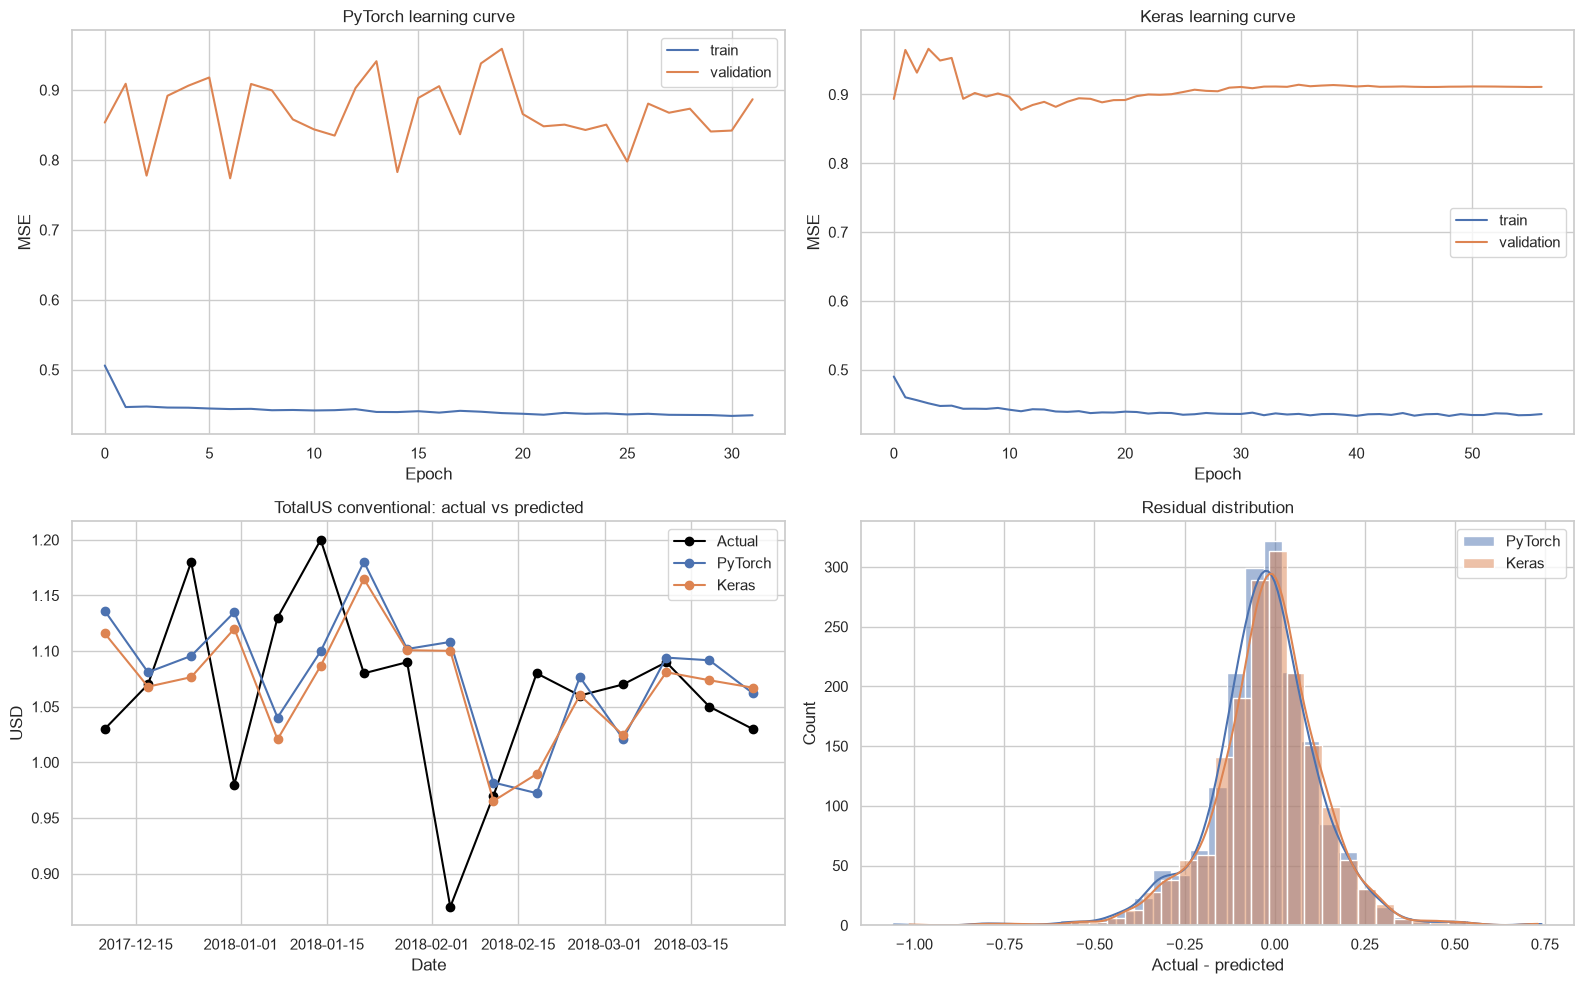

In [14]:
def inverse_by_group(scaled_values, group_keys):
    output = np.empty(len(scaled_values), dtype=np.float64)
    for index, (value, key) in enumerate(zip(scaled_values, group_keys)):
        scaler_info = group_scalers[key]
        output[index] = value * scaler_info["scale"] + scaler_info["mean"]
    return output

torch_prediction = inverse_by_group(torch_scaled_prediction, test_group_keys)
keras_prediction = inverse_by_group(keras_scaled_prediction, test_group_keys)
predictions = {
    "Persistence baseline": baseline_test,
    "PyTorch RNN": torch_prediction,
    "Keras RNN": keras_prediction,
}
results = []
for name, prediction in predictions.items():
    row = {"Model": name, **regression_metrics(y_test_raw, prediction)}
    if name == "PyTorch RNN":
        row["Train time (s)"] = torch_train_seconds
    elif name == "Keras RNN":
        row["Train time (s)"] = keras_train_seconds
    else:
        row["Train time (s)"] = 0.0
    results.append(row)
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
display(results_df.style.format({column: "{:.4f}" for column in results_df.columns}))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(torch_history["loss"], label="train")
axes[0, 0].plot(torch_history["val_loss"], label="validation")
axes[0, 0].set(title="PyTorch learning curve", xlabel="Epoch", ylabel="MSE")
axes[0, 0].legend()
axes[0, 1].plot(keras_history["loss"], label="train")
axes[0, 1].plot(keras_history["val_loss"], label="validation")
axes[0, 1].set(title="Keras learning curve", xlabel="Epoch", ylabel="MSE")
axes[0, 1].legend()

focus_key = f"TotalUS{GROUP_SEPARATOR}conventional"
focus = test_group_keys == focus_key
focus_order = np.argsort(test_dates[focus])
axes[1, 0].plot(test_dates[focus][focus_order], y_test_raw[focus][focus_order], marker="o", label="Actual", color="black")
axes[1, 0].plot(test_dates[focus][focus_order], torch_prediction[focus][focus_order], marker="o", label="PyTorch")
axes[1, 0].plot(test_dates[focus][focus_order], keras_prediction[focus][focus_order], marker="o", label="Keras")
axes[1, 0].set(title="TotalUS conventional: actual vs predicted", xlabel="Date", ylabel="USD")
axes[1, 0].legend()
sns.histplot(y_test_raw - torch_prediction, bins=35, kde=True, ax=axes[1, 1], label="PyTorch", alpha=0.5)
sns.histplot(y_test_raw - keras_prediction, bins=35, kde=True, ax=axes[1, 1], label="Keras", alpha=0.5)
axes[1, 1].set(title="Residual distribution", xlabel="Actual - predicted")
axes[1, 1].legend()
plt.tight_layout()
plt.show()


## 12. Lưu metadata và kiểm chứng khả năng deploy

Metadata lưu 108 scaler `region–type`, danh sách nhóm, lookback, kiến trúc và tên artifacts.
Hai model mới được dựng và nạp weights để xác nhận file deploy có thể tái tạo inference.


In [15]:
metadata = {
    "dataset": "Avocado Price",
    "target": "AveragePrice",
    "lookback": LOOKBACK,
    "split": {"train": len(X_train), "validation": len(X_val), "test": len(X_test)},
    "group_scalers": group_scalers,
    "groups": groups_metadata,
    "model_config": MODEL_CONFIG,
    "training_config": {
        "max_epochs": MAX_EPOCHS,
        "min_epochs": MIN_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    },
    "artifacts": {"pytorch": PYTORCH_WEIGHTS_PATH.name, "keras": KERAS_WEIGHTS_PATH.name},
    "training_device": str(DEVICE),
    "framework_versions": {"torch": torch.__version__, "tensorflow": tf.__version__},
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

reloaded_torch = TorchPriceRNN().to(DEVICE)
try:
    checkpoint = torch.load(PYTORCH_WEIGHTS_PATH, map_location=DEVICE, weights_only=True)
except TypeError:
    checkpoint = torch.load(PYTORCH_WEIGHTS_PATH, map_location=DEVICE)
reloaded_torch.load_state_dict(checkpoint["state_dict"])
reloaded_torch_value = predict_torch(reloaded_torch, X_test[:1])[0]

reloaded_keras = build_keras_rnn(MODEL_NAME)
reloaded_keras.load_weights(KERAS_WEIGHTS_PATH)
reloaded_keras_value = reloaded_keras.predict(X_test[:1], verbose=0).reshape(-1)[0]
assert np.allclose(reloaded_torch_value, torch_scaled_prediction[0], atol=1e-6)
assert np.allclose(reloaded_keras_value, keras_scaled_prediction[0], atol=1e-6)
assert PYTORCH_WEIGHTS_PATH.exists() and KERAS_WEIGHTS_PATH.exists() and METADATA_PATH.exists()
print("Reload verification: PASS")
print("Artifacts:", PYTORCH_WEIGHTS_PATH, KERAS_WEIGHTS_PATH, METADATA_PATH, sep="\n- ")


Reload verification: PASS
Artifacts:
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Avocado Price/models/pytorch_rnn.pt
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Avocado Price/models/keras_rnn.weights.h5
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Avocado Price/models/metadata.json


/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(store)


## 13. Kết luận

Metric test tổng hợp trên toàn bộ 108 chuỗi cho biết RNN có vượt baseline persistence hay không.
Kết quả `TotalUS–conventional` minh họa cách đọc dự báo của một nhóm cụ thể. Best weights và
toàn bộ scaler train-only đã sẵn sàng cho `deploy.py --framework pytorch|keras`.
